# 4.1 Financials — EDA

Explores daily market data (S&P 500, Oil, VIX, 10Y Bond, USD Index) and monthly macro indicators
(Unemployment, CPI, Consumer Sentiment, Real Disposable Income, Real GDP) over **June – November 2024**.

**Input:** `Data/1_Bronze/Financials/market.csv` · `macros.csv`


<!-- toc -->
## Contents
- [Setup](#setup)
- [1. General](#1-general)
  - [1.1 Data Overview](#11-data-overview)
  - [1.2 Market Indicators Over Time](#12-market-indicators-over-time)
  - [1.3 Correlation Between Market Indicators](#13-correlation-between-market-indicators)
  - [1.4 S&P 500 vs. Market Volatility (VIX)](#14-sp-500-vs-market-volatility-vix)
  - [1.5 Macroeconomic Indicators](#15-macroeconomic-indicators)
- [2. Events](#2-events)
  - [2.1 Market Reaction Around Each Event](#21-market-reaction-around-each-event)
  - [2.2 Indexed Performance Around Events](#22-indexed-performance-around-events)
  - [2.3 Market Impact Summary](#23-market-impact-summary)


## Setup

In [13]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

sys.path.insert(0, '../..')
from house_style import *
apply_style()

In [14]:
ROOT   = Path('../../Data/1_Bronze/Financials')
market = pd.read_csv(ROOT / 'market.csv', parse_dates=['Date'])
macros = pd.read_csv(ROOT / 'macros.csv', parse_dates=['DATE'])
market = market.sort_values('Date').reset_index(drop=True)
macros = macros.sort_values('DATE').reset_index(drop=True)

# EVENTS and EVENT_PALETTE are imported from house_style

def event_window(df, event_date, days_before=10, days_after=10):
    lo = pd.Timestamp(event_date) - pd.Timedelta(days=days_before)
    hi = pd.Timestamp(event_date) + pd.Timedelta(days=days_after)
    return df[(df['Date'] >= lo) & (df['Date'] <= hi)].copy()

print(f"Market : {len(market)} trading days | {market['Date'].min().date()} → {market['Date'].max().date()}")
print(f"Macros : {len(macros)} months       | {macros['DATE'].min().date()} → {macros['DATE'].max().date()}")

Market : 85 trading days | 2024-07-05 → 2024-11-01
Macros : 4 months       | 2024-08-01 → 2024-11-01


## 1. General

### 1.1 Data Overview

In [15]:
print('=== MARKET DATA (daily) ===')
display(market.head())
print(f'\nShape: {market.shape}')
display(market.describe().round(2))

print('\n=== MACROECONOMIC DATA (monthly) ===')
display(macros)

=== MARKET DATA (daily) ===


,Date,SP500,Oil,VIX,TenYearBond,USDIndex
0,2024-07-05,5567.189941,83.160004,12.48,4.272,104.879997
1,2024-07-08,5572.850098,82.330002,12.37,4.269,105.010002
2,2024-07-09,5576.979980,81.410004,12.51,4.300,105.120003
3,2024-07-10,5633.910156,82.099998,12.85,4.280,105.050003
4,2024-07-11,5584.540039,82.620003,12.92,4.193,104.440002



Shape: (85, 6)


,Date,SP500,Oil,VIX,TenYearBond,USDIndex
count,85,85.00,85.00,85.00,85.00,85.00
mean,2024-09-03 07:20:28.235294208,5614.27,73.92,18.16,3.98,102.75
min,2024-07-05 00:00:00,5186.33,65.75,12.37,3.62,100.37
25%,2024-08-05 00:00:00,5522.30,70.19,15.88,3.79,101.36
50%,2024-09-04 00:00:00,5618.26,73.55,17.69,3.97,102.97
75%,2024-10-03 00:00:00,5732.93,76.98,19.90,4.19,104.17
max,2024-11-01 00:00:00,5864.67,83.16,38.57,4.36,105.12
std,NaN,159.28,4.57,3.86,0.21,1.45



=== MACROECONOMIC DATA (monthly) ===


,DATE,RealDisposableIncome,RealGDP,UnemploymentRate,CPIInflation,ConsumerSentiment
0,2024-08-01,17752.9,NaN,4.2,314.062,67.9
1,2024-09-01,17769.9,NaN,4.1,314.732,70.1
2,2024-10-01,17810.5,23586.542,4.1,315.631,70.5
3,2024-11-01,17851.4,NaN,4.2,316.528,71.8


### 1.2 Market Indicators Over Time

Five daily indicators stacked. Thin line = raw daily values; thick line = 5-day rolling mean.
Dashed vertical lines mark the four political events.

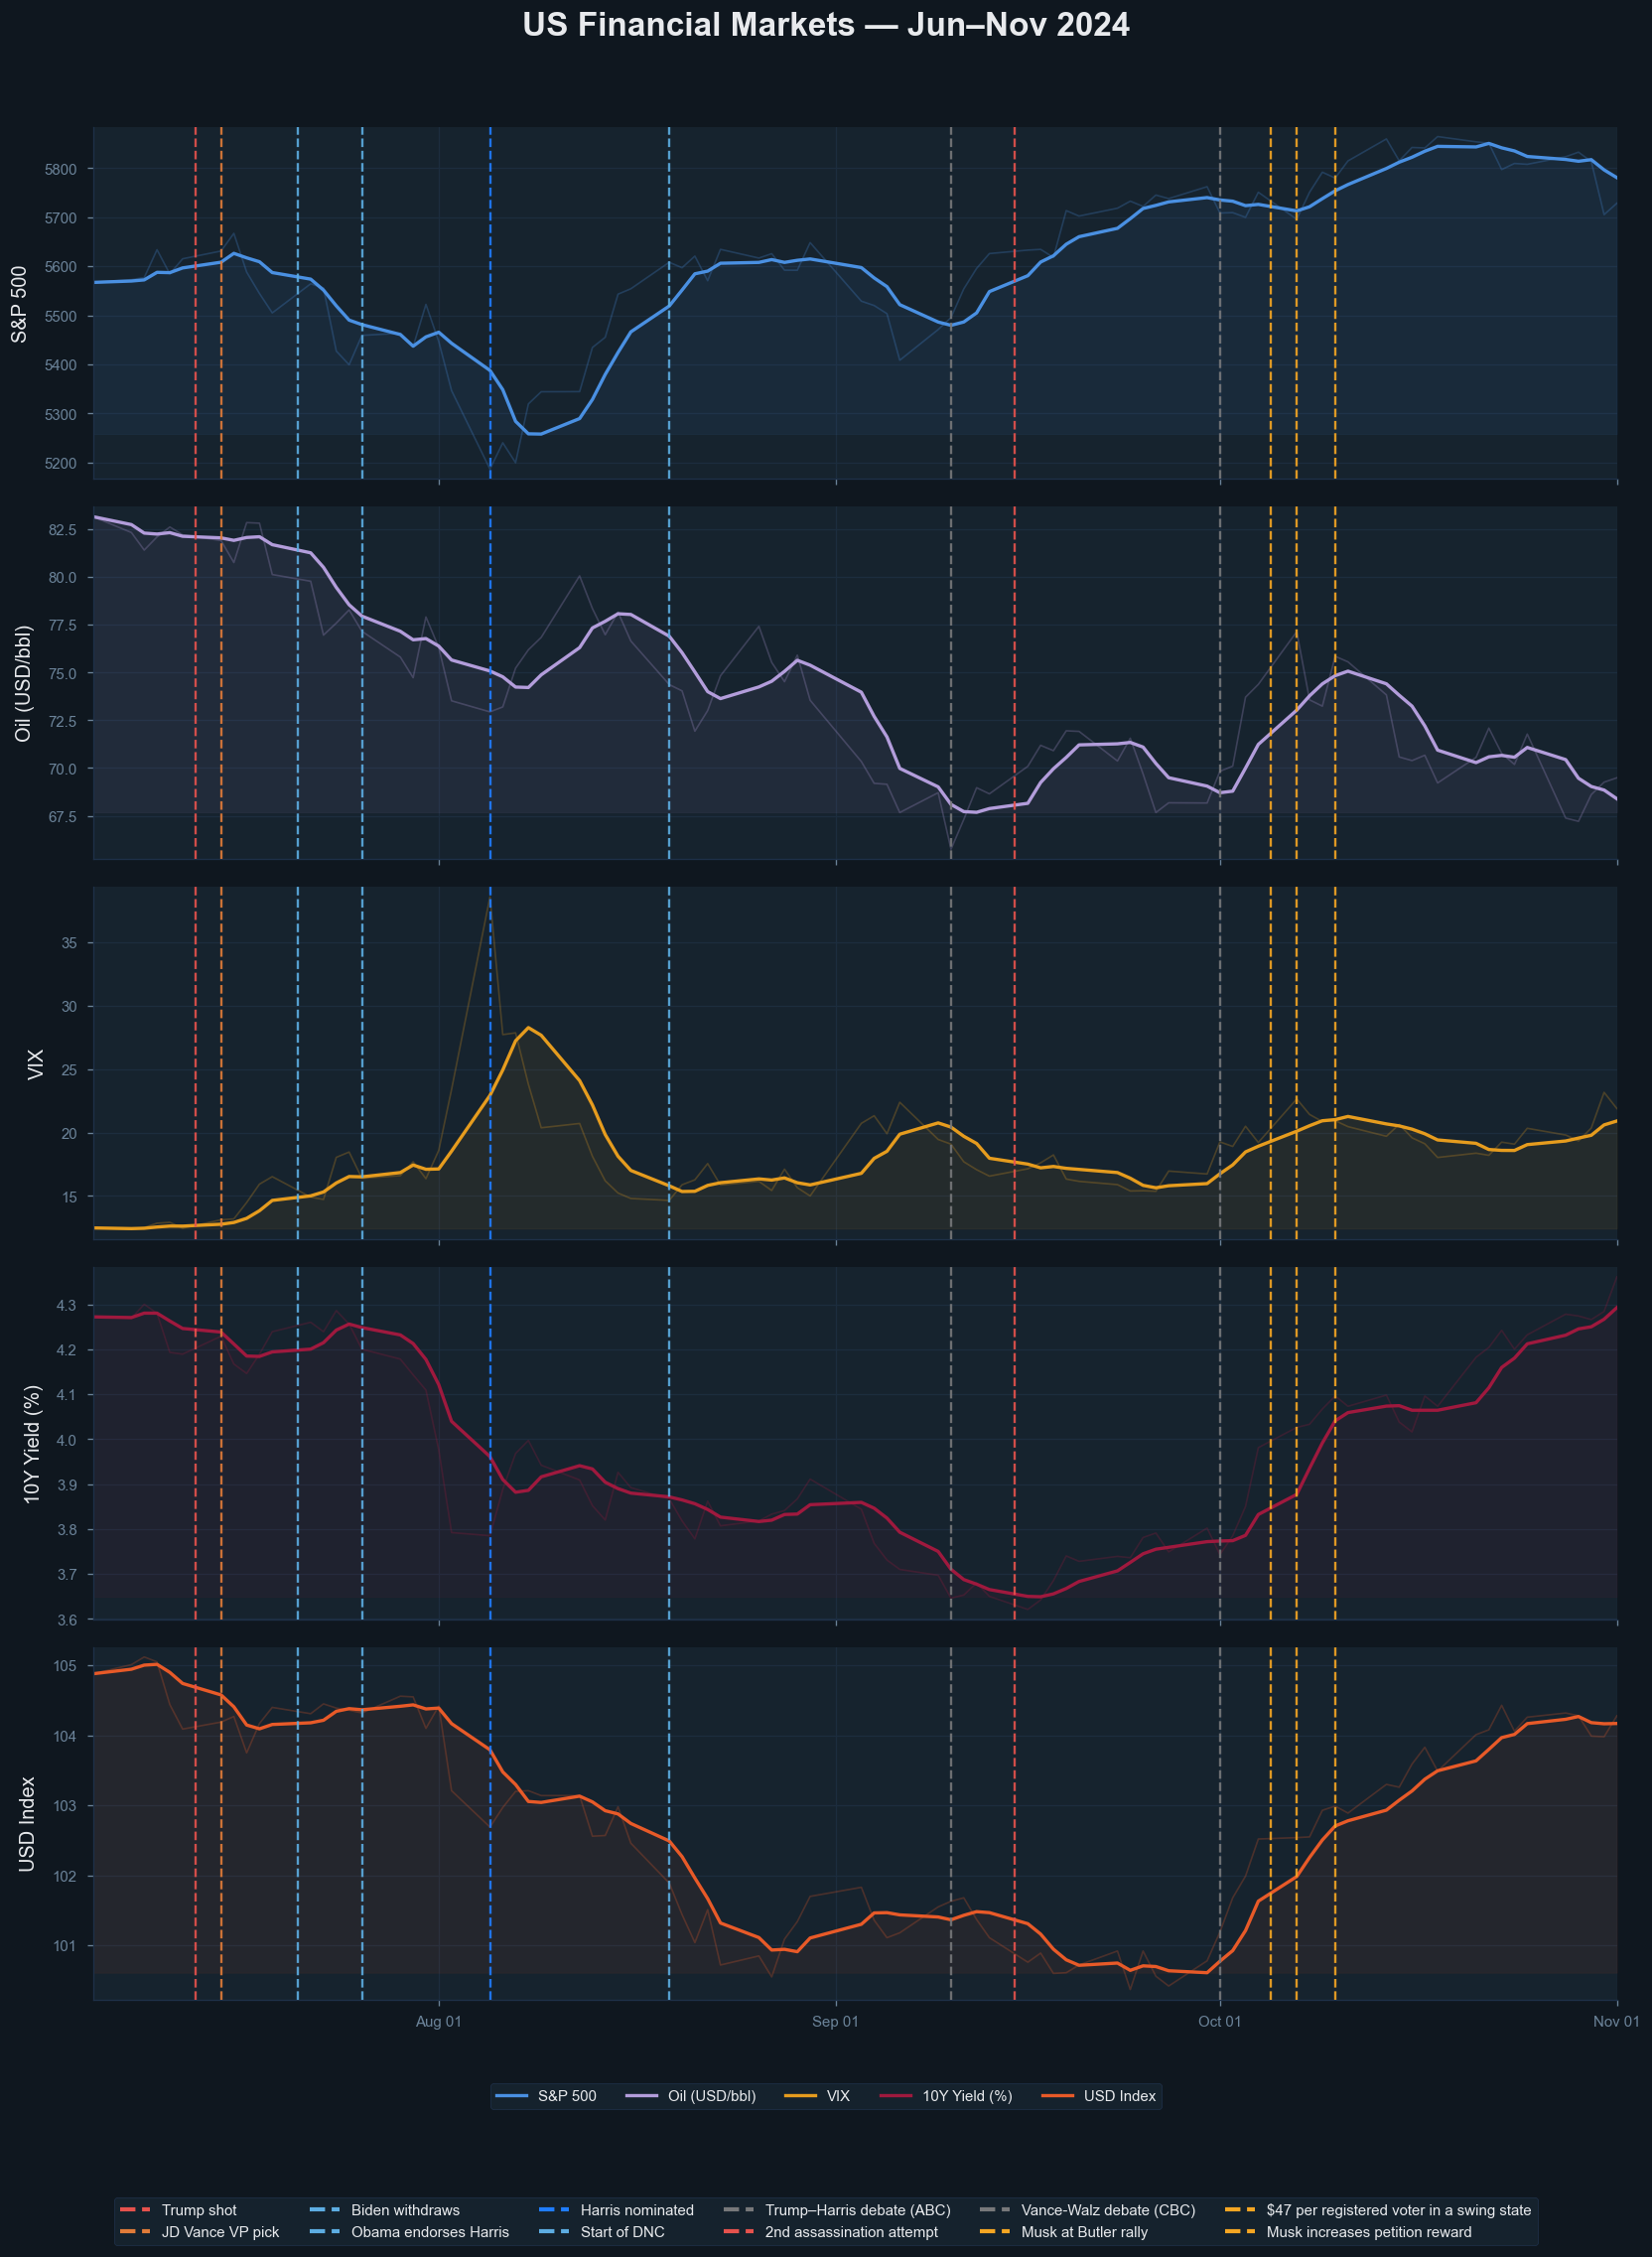

In [16]:
import matplotlib.lines as mlines

MARKET_COLS = ["SP500", "Oil", "VIX", "TenYearBond", "USDIndex"]
YLABELS     = ["S&P 500", "Oil (USD/bbl)", "VIX", "10Y Yield (%)", "USD Index"]

fig, axes = styled_fig(
    nrows=5, ncols=1, figsize=(14, 19),
    title="US Financial Markets — Jun–Nov 2024",
    sharex=True
)
fig.subplots_adjust(hspace=0.08)

MARKET_COLORS = {
    "SP500":       C_SP500,
    "Oil":         "#b39ddb",
    "VIX":         C_VIX,
    "TenYearBond": "#9f193e",
    "USDIndex":    "#e85a28",
}
market_handles = []
for i, (col, ylabel) in enumerate(zip(MARKET_COLS, YLABELS)):
    ax   = axes[i]
    raw  = market[col]
    roll = raw.rolling(5, min_periods=1).mean()
    c    = MARKET_COLORS[col]
    ax.plot(market["Date"], raw,  color=c, alpha=0.25, linewidth=1)
    line, = ax.plot(market["Date"], roll, color=c, linewidth=2, label=ylabel)
    market_handles.append(line)
    ax.fill_between(market["Date"], roll, roll.min(), color=c, alpha=0.07)
    add_events(ax)
    style_ax(ax, ylabel=ylabel)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[-1].get_xticklabels(), rotation=0, ha="center")
axes[0].set_xlim(market["Date"].min(), market["Date"].max())

place_legends_bottom(
    axes[0],
    main_handles=market_handles,
    main_ncol=5,
    main_y=0.09,
    event_handles=event_legend_handles(),
    event_ncol=6,
    event_y=0.03,
)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("../../latex_template/figures/financials_market_overview.png", dpi=150, bbox_inches="tight", facecolor=BG_DARK)
plt.show()


### 1.3 Correlation Between Market Indicators

Pearson correlation matrix of the five daily market variables.

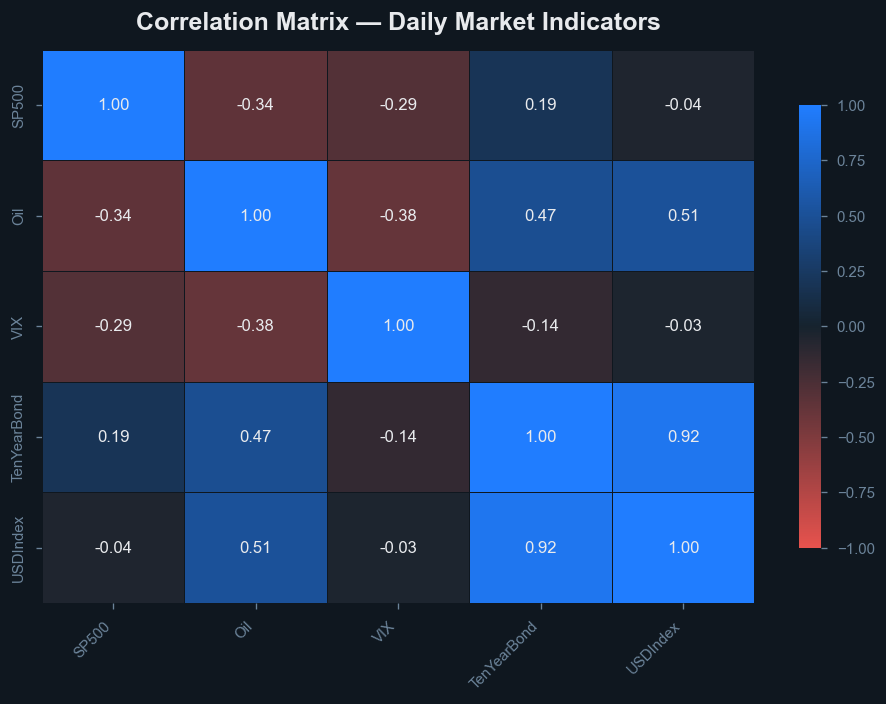

In [17]:
corr = market[MARKET_COLS].corr()

fig, ax = styled_fig(figsize=(8, 6))

cmap = LinearSegmentedColormap.from_list(
    'house_div', [REPUBLICAN, BG_PANEL, DEMOCRAT], N=256
)
sns.heatmap(
    corr, ax=ax, annot=True, fmt='.2f', cmap=cmap,
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor=BG_DARK,
    annot_kws={'size': 10, 'color': TEXT_PRIMARY},
    cbar_kws={'shrink': 0.8},
)
ax.set_facecolor(BG_PANEL)
for tick, col in zip(ax.get_xticklabels(), MARKET_COLS):
    tick.set_color(MARKET_COLORS[col])
    tick.set_rotation(45)
    tick.set_ha('right')
for tick, col in zip(ax.get_yticklabels(), MARKET_COLS):
    tick.set_color(MARKET_COLORS[col])
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors=TEXT_MUTED)
style_ax(ax, title='Correlation Matrix — Daily Market Indicators')
plt.tight_layout()
plt.savefig("../../latex_template/figures/financials_correlation.png", dpi=150, bbox_inches="tight", facecolor=BG_DARK)
plt.show()


### 1.4 S&P 500 vs. Market Volatility (VIX)

Left axis: S&P 500 daily close. Right axis: VIX 10-day rolling mean (shaded).
The inverse relationship between equity levels and volatility is clearly visible around the events.

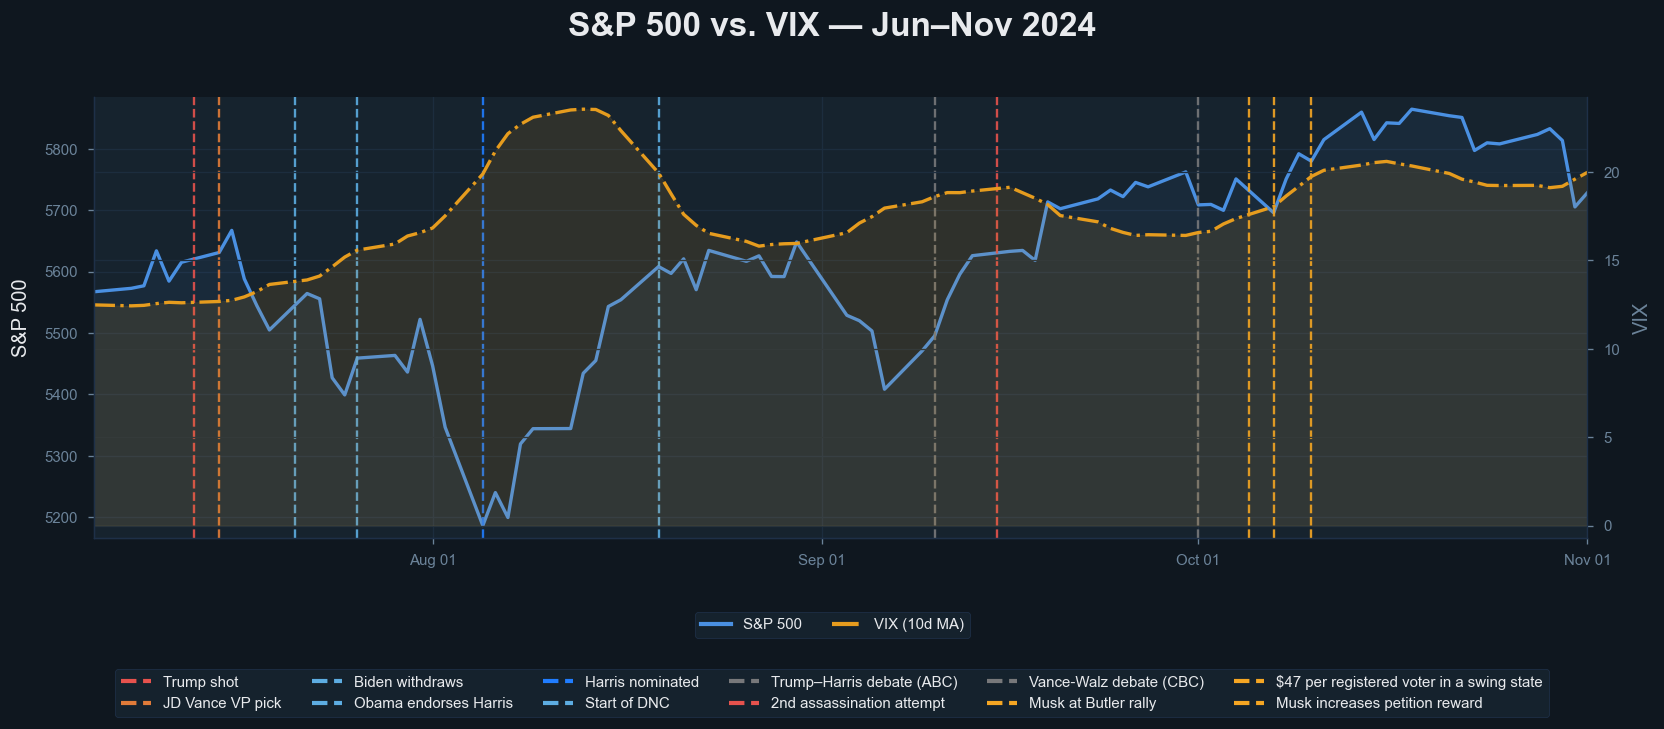

In [18]:
import matplotlib.lines as mlines

fig, ax1 = styled_fig(figsize=(14, 6), title="S&P 500 vs. VIX — Jun–Nov 2024")

ax1.plot(market["Date"], market["SP500"], color=C_SP500, linewidth=2, label="S&P 500")
ax1.fill_between(
    market["Date"], market["SP500"], market["SP500"].min(),
    color=C_SP500, alpha=0.07
)
style_ax(ax1, ylabel="S&P 500")

ax2      = ax1.twinx()
vix_roll = market["VIX"].rolling(10, min_periods=1).mean()
ax2.plot(market["Date"], vix_roll, color=C_VIX, linewidth=2,
         linestyle="-.", label="VIX (10d MA)")
ax2.fill_between(market["Date"], vix_roll, 0, color=C_VIX, alpha=0.12)
ax2.set_ylabel("VIX", color=TEXT_MUTED)
ax2.tick_params(axis="y", colors=TEXT_MUTED)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_edgecolor(SPINE_COLOR)
ax2.set_facecolor("none")

add_events(ax1)

ax1.set_xlim(market["Date"].min(), market["Date"].max())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

data_handles = [
    mlines.Line2D([], [], color=C_SP500, linewidth=2.5, label="S&P 500"),
    mlines.Line2D([], [], color=C_VIX, linewidth=2.5, linestyle="-.", label="VIX (10d MA)"),
]
place_legends_bottom(
    ax1,
    main_handles=data_handles,
    main_ncol=2,
    main_y=0.14,
    event_handles=event_legend_handles(),
    event_ncol=6,
    event_y=0.03,
)
plt.tight_layout(rect=[0, 0.22, 1, 1])
plt.savefig("../../latex_template/figures/financials_sp500_vix.png", dpi=150, bbox_inches="tight", facecolor=BG_DARK)
plt.show()


### 1.5 Macroeconomic Indicators

Monthly snapshot of five macro series. Real GDP is quarterly (only 2 data points in the window).

C:\Users\verme_hzys4y0\AppData\Local\Temp\ipykernel_10888\3631580731.py:26: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(sub['DATE'].min(), sub['DATE'].max())


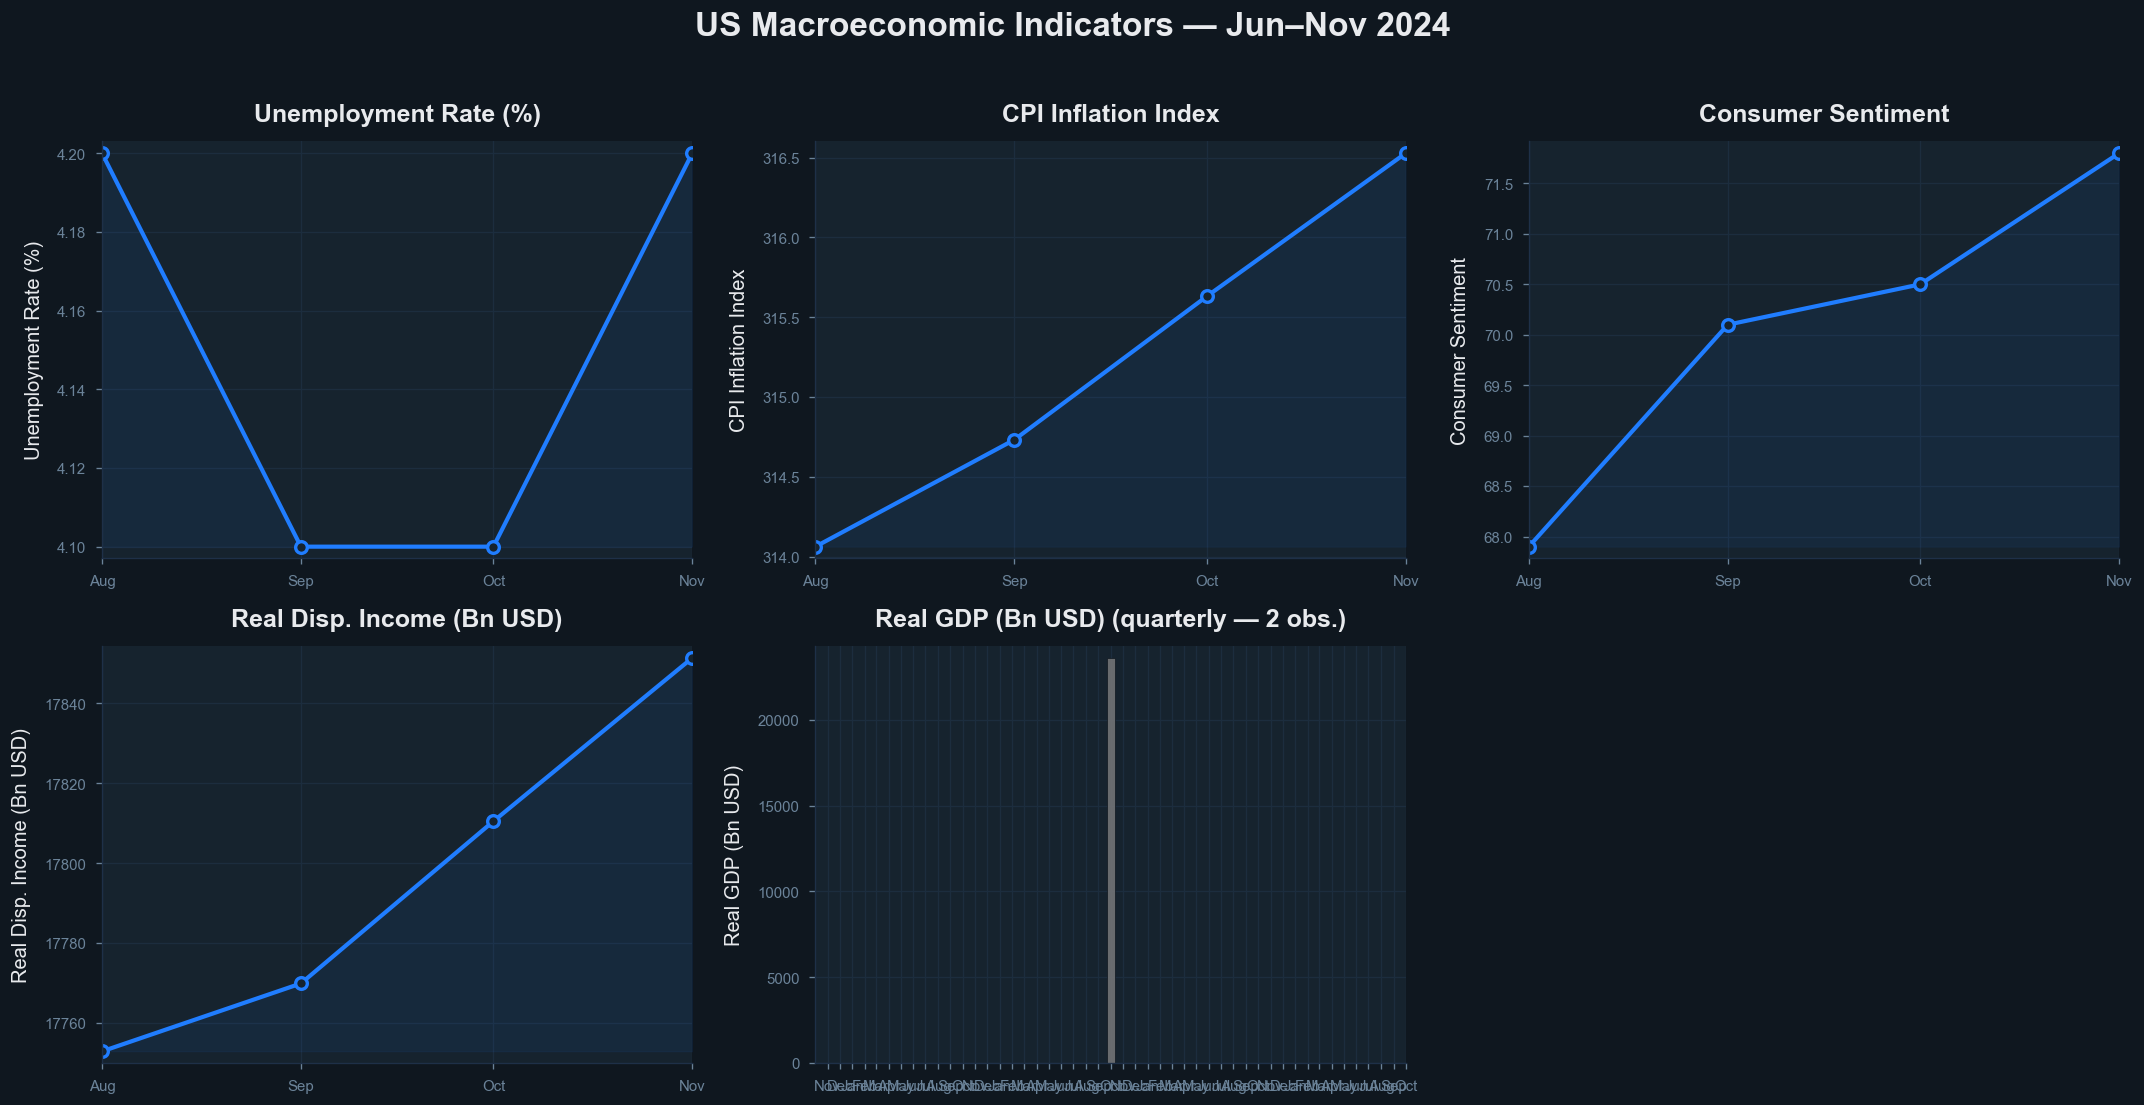

In [19]:
MACRO_COLS   = ['UnemploymentRate', 'CPIInflation', 'ConsumerSentiment',
                'RealDisposableIncome', 'RealGDP']
MACRO_LABELS = ['Unemployment Rate (%)', 'CPI Inflation Index',
                'Consumer Sentiment', 'Real Disp. Income (Bn USD)', 'Real GDP (Bn USD)']

fig, axes = styled_fig(
    nrows=2, ncols=3, figsize=(18, 9),
    title='US Macroeconomic Indicators — Jun–Nov 2024'
)
fig.subplots_adjust(hspace=0.45, wspace=0.35)

for i, (col, lbl) in enumerate(zip(MACRO_COLS, MACRO_LABELS)):
    ax  = axes[i // 3][i % 3]
    sub = macros[['DATE', col]].dropna()
    if col == 'RealGDP':
        ax.bar(sub['DATE'], sub[col], width=20, color=PALETTE[2],
               alpha=0.85, edgecolor=BG_DARK)
        title_str = lbl + ' (quarterly — 2 obs.)'
    else:
        ax.plot(sub['DATE'], sub[col], color=PALETTE[0], linewidth=2.5,
                marker='o', markersize=7,
                markerfacecolor=BG_PANEL, markeredgecolor=PALETTE[0], markeredgewidth=2)
        ax.fill_between(sub['DATE'], sub[col], sub[col].min(),
                        color=PALETTE[0], alpha=0.07)
        title_str = lbl
    ax.set_xlim(sub['DATE'].min(), sub['DATE'].max())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    style_ax(ax, ylabel=lbl, title=title_str)

axes[1][2].set_visible(False)
plt.tight_layout()
plt.show()

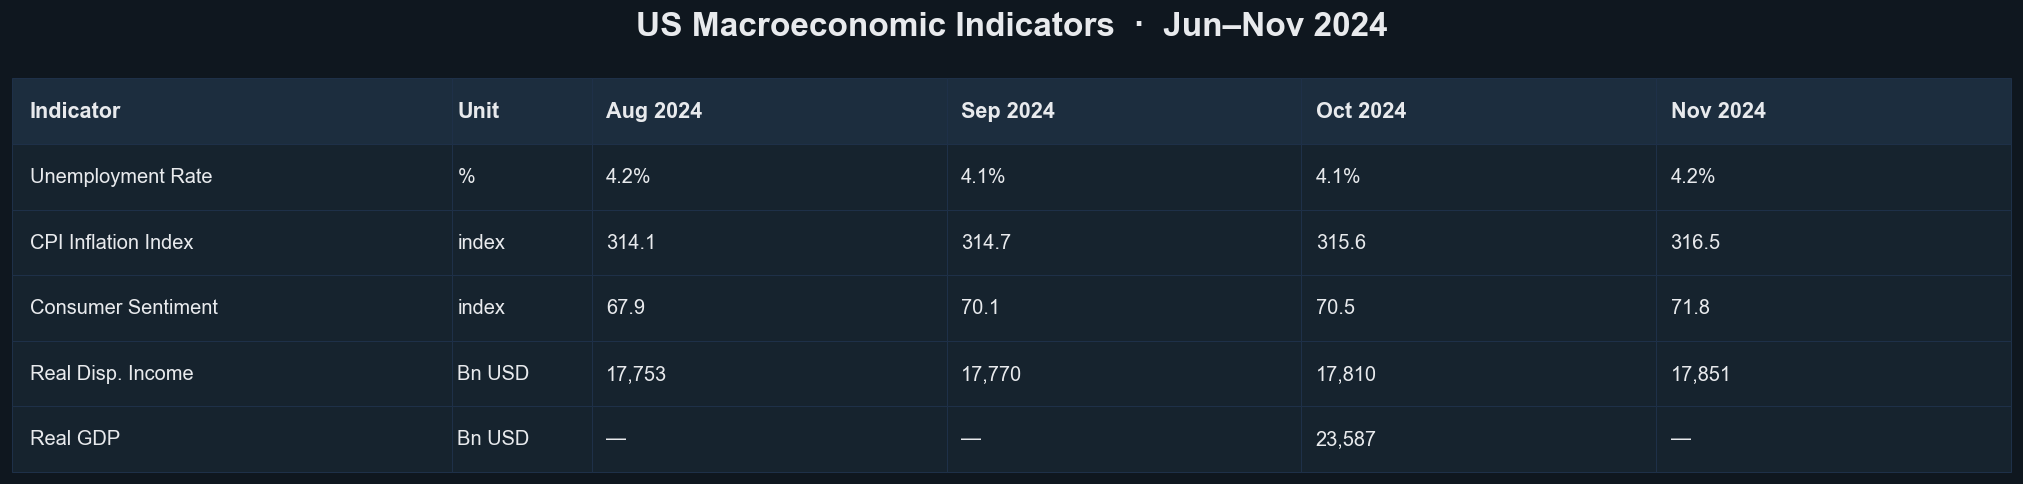

In [20]:
MACRO_DISPLAY = {
    'UnemploymentRate':     ('Unemployment Rate',   '%'),
    'CPIInflation':         ('CPI Inflation Index', 'index'),
    'ConsumerSentiment':    ('Consumer Sentiment',  'index'),
    'RealDisposableIncome': ('Real Disp. Income',   'Bn USD'),
    'RealGDP':              ('Real GDP',            'Bn USD'),
}
FORMAT = {
    'UnemploymentRate':     lambda v: f'{v:.1f}%',
    'CPIInflation':         lambda v: f'{v:.1f}',
    'ConsumerSentiment':    lambda v: f'{v:.1f}',
    'RealDisposableIncome': lambda v: f'{v:,.0f}',
    'RealGDP':              lambda v: f'{v:,.0f}',
}

dates_sorted = sorted(macros['DATE'].dropna().unique())
month_labels = [pd.Timestamp(d).strftime('%b %Y') for d in dates_sorted]
col_labels   = ['Indicator', 'Unit'] + month_labels
n_cols       = len(col_labels)
col_widths   = [0.22, 0.07] + [round(0.71 / max(len(month_labels), 1), 4)] * len(month_labels)

table_data, table_colors = [], []
for col, (name, unit) in MACRO_DISPLAY.items():
    row = [name, unit]
    for d in dates_sorted:
        match = macros[macros['DATE'] == d]
        if not match.empty and col in match.columns and not pd.isna(match.iloc[0][col]):
            row.append(FORMAT[col](match.iloc[0][col]))
        else:
            row.append('—')
    table_data.append(row)
    table_colors.append([BG_PANEL] * n_cols)

fig_m = plt.figure(figsize=(17, 4), facecolor=BG_DARK)
ax_m = fig_m.add_axes([0.01, 0.02, 0.98, 0.82])
ax_m.set_facecolor(BG_DARK)
ax_m.axis('off')

tbl = ax_m.table(
    cellText    = table_data,
    colLabels   = col_labels,
    colWidths   = col_widths,
    cellColours = table_colors,
    colColours  = ['#1c2d3e'] * n_cols,
    loc         = 'upper center',
    bbox        = [0, 0, 1, 1],
)
tbl.auto_set_font_size(False)

for (row, col_i), cell in tbl.get_celld().items():
    cell.set_edgecolor(SPINE_COLOR)
    cell.set_linewidth(0.6)
    cell.PAD = 0.04
    cell.get_text().set_ha('left')
    if row == 0:
        cell.set_facecolor('#1c2d3e')
        cell.set_text_props(color=TEXT_PRIMARY, fontweight='bold', fontsize=13, ha='left')
    else:
        cell.set_facecolor(BG_PANEL)
        cell.set_text_props(color=TEXT_PRIMARY, fontsize=12, ha='left')

fig_m.suptitle('US Macroeconomic Indicators  ·  Jun–Nov 2024',
               color=TEXT_PRIMARY, fontweight='bold', y=0.98)
plt.savefig("../../latex_template/figures/financials_macro_table.png",
            dpi=150, bbox_inches="tight", facecolor=BG_DARK)
plt.show()


## 2. Events

Six key political events during the 2024 US election campaign:

Six key political events during the 2024 US election campaign:

| # | Event | Date | Colour |
|---|-------|------|--------|
| 1 | Trump assassination attempt | 2024-07-13 | Red (Republican) |
| 2 | Trump announces JD Vance as VP | 2024-07-15 | Orange |
| 3 | Biden withdraws | 2024-07-21 | Blue (Democrat) |
| 4 | Harris announced as Democratic nominee | 2024-08-05 | Light blue |
| 5 | Trump–Harris debate hosted by ABC | 2024-09-10 | Grey (Neutral) |
| 6 | 2nd assassination attempt on Trump | 2024-09-15 | Dark red |

Each event is examined over a **±10 calendar-day window** of daily market data.

### 2.1 Market Reaction Around Each Event

4 × 2 grid: **left panel** shows S&P 500 (left y) + VIX (right y);
**right panel** shows Oil (left y) + USD Index (right y).
The vertical dashed line marks the exact event date.

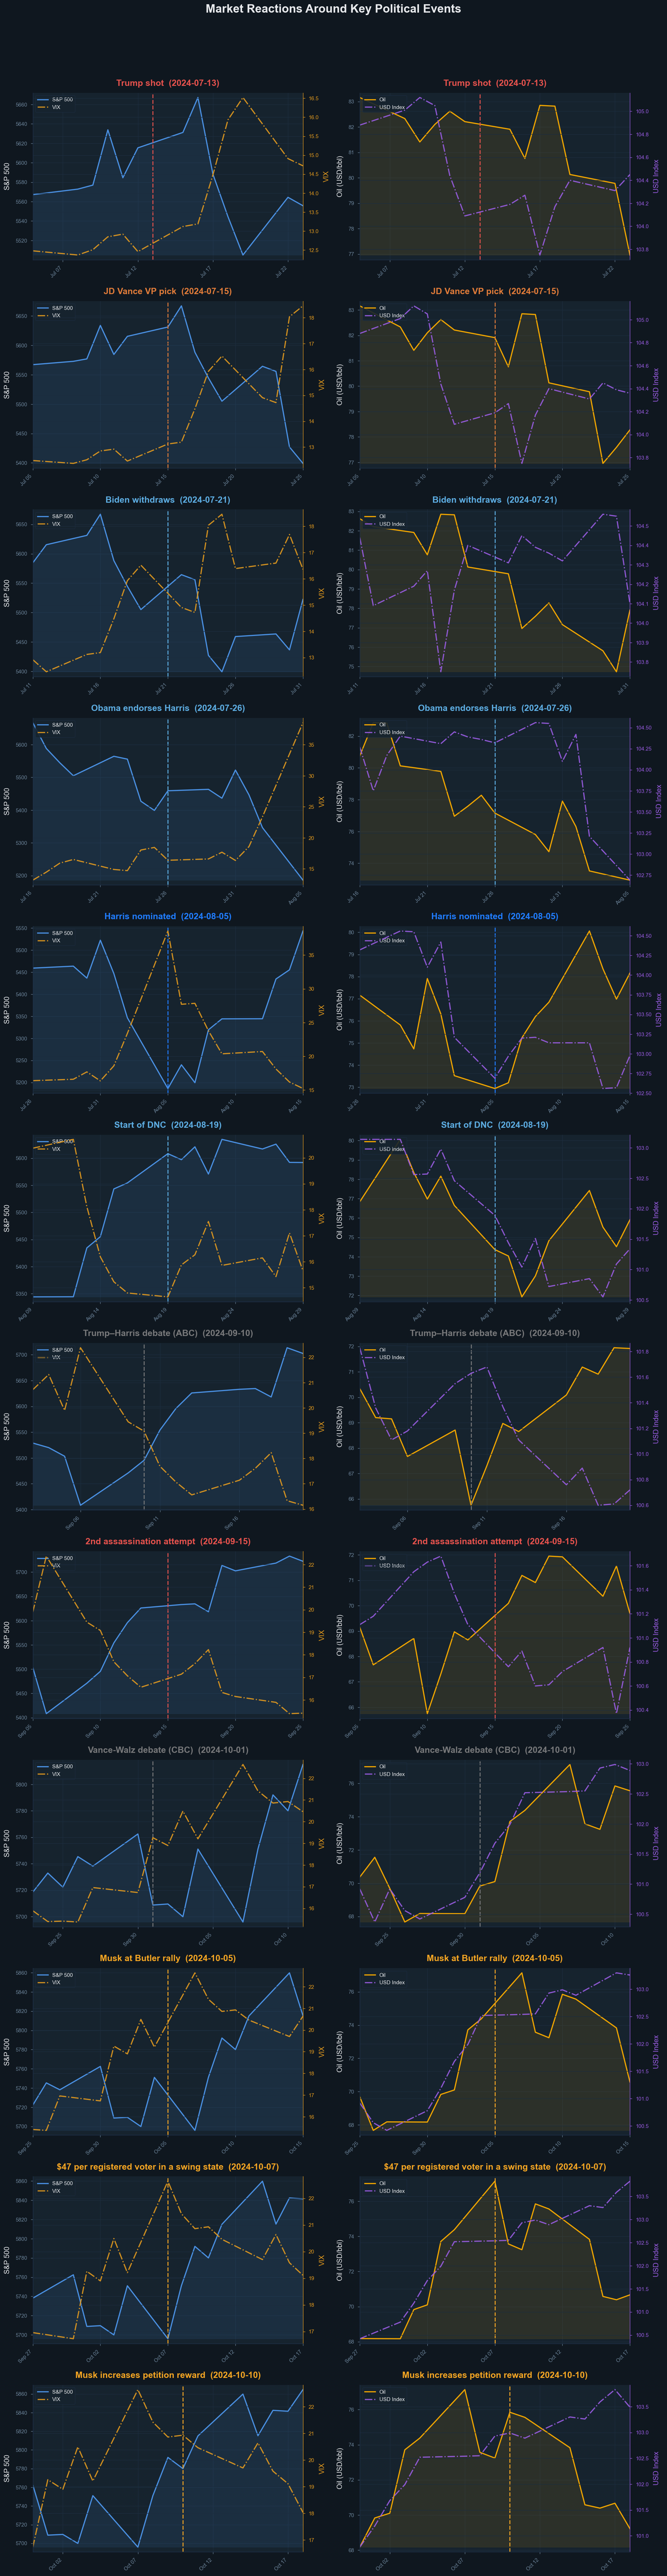

In [21]:
fig, axes = styled_fig(
    nrows=len(EVENTS), ncols=2, figsize=(16, len(EVENTS)*5),
    title="Market Reactions Around Key Political Events"
)
fig.subplots_adjust(hspace=0.48, wspace=0.32)

for row, (lbl, date, event_color) in enumerate(EVENTS):
    ev  = pd.Timestamp(date)
    win = event_window(market, date, days_before=10, days_after=10)

    ax_l  = axes[row][0]
    ax_l2 = ax_l.twinx()
    ax_l.plot(win["Date"], win["SP500"], color=C_SP500, linewidth=2, label="S&P 500")
    ax_l.fill_between(win["Date"], win["SP500"], win["SP500"].min(),
                      color=C_SP500, alpha=0.10)
    ax_l.axvline(ev, color=event_color, linestyle="--", linewidth=1.8, alpha=0.9)
    style_ax(ax_l, ylabel="S&P 500")
    ax_l.set_title(f"{lbl}  ({date})", color=event_color, fontweight="bold")
    ax_l.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax_l.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.setp(ax_l.get_xticklabels(), rotation=45, ha="right")
    ax_l2.plot(win["Date"], win["VIX"], color=C_VIX, linewidth=2,
               linestyle="-.", label="VIX", alpha=0.9)
    ax_l2.set_ylabel("VIX", color=C_VIX)
    ax_l2.tick_params(axis="y", colors=C_VIX)
    ax_l2.spines["right"].set_visible(True)
    ax_l2.spines["right"].set_edgecolor(C_VIX)
    ax_l2.set_facecolor("none")
    ll, nl   = ax_l.get_legend_handles_labels()
    ll2, nl2 = ax_l2.get_legend_handles_labels()
    ax_l.legend(ll + ll2, nl + nl2, fontsize=9, loc="upper left",
                facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

    ax_r  = axes[row][1]
    ax_r2 = ax_r.twinx()
    ax_r.plot(win["Date"], win["Oil"], color='#f0a500', linewidth=2, label="Oil")
    ax_r.fill_between(win["Date"], win["Oil"], win["Oil"].min(),
                      color='#f0a500', alpha=0.10)
    ax_r.axvline(ev, color=event_color, linestyle="--", linewidth=1.8, alpha=0.9)
    style_ax(ax_r, ylabel="Oil (USD/bbl)")
    ax_r.set_title(f"{lbl}  ({date})", color=event_color, fontweight="bold")
    ax_r.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax_r.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.setp(ax_r.get_xticklabels(), rotation=45, ha="right")
    ax_r2.plot(win["Date"], win["USDIndex"], color='#9b5de5', linewidth=2,
               linestyle="-.", label="USD Index", alpha=0.9)
    ax_r2.set_ylabel("USD Index", color='#9b5de5')
    ax_r2.tick_params(axis="y", colors='#9b5de5')
    ax_r2.spines["right"].set_visible(True)
    ax_r2.spines["right"].set_edgecolor('#9b5de5')
    ax_r2.set_facecolor("none")
    lr, nr   = ax_r.get_legend_handles_labels()
    lr2, nr2 = ax_r2.get_legend_handles_labels()
    ax_r.legend(lr + lr2, nr + nr2, fontsize=9, loc="upper left",
                facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()


### 2.2 Indexed Performance Around Events

Each event window is indexed to **100 on the event day (t = 0)**.
This normalises away level differences and makes relative reactions directly comparable.
Left: S&P 500 ±7 calendar days. Right: VIX ±7 calendar days.

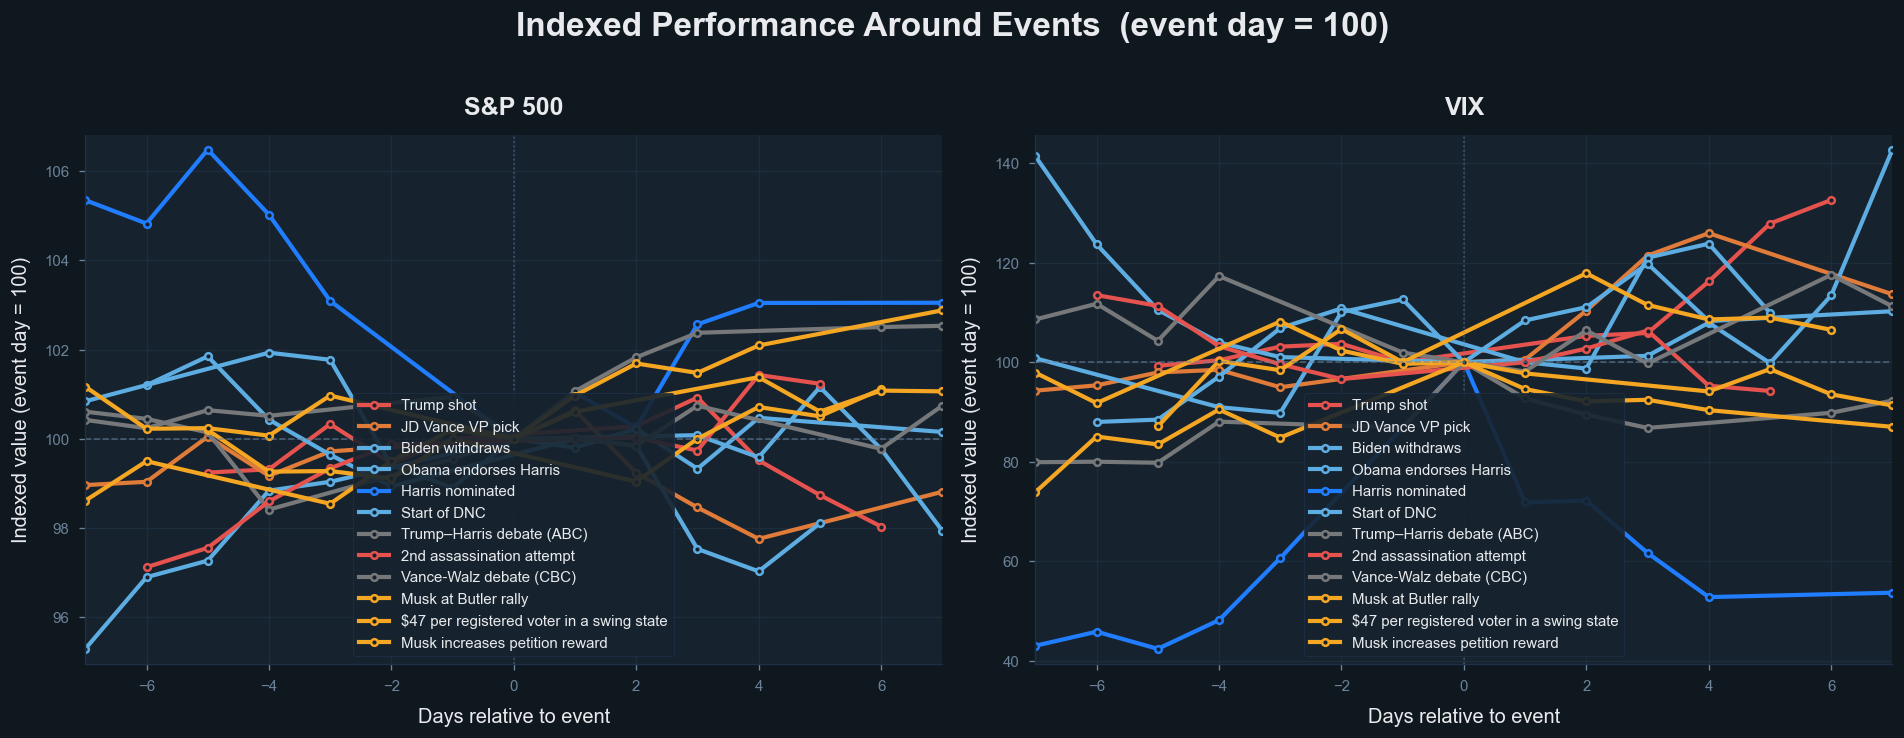

In [22]:
def index_at_event(df, col, event_date_str, days_before=7, days_after=7):
    ev      = pd.Timestamp(event_date_str)
    lo      = ev - pd.Timedelta(days=days_before)
    hi      = ev + pd.Timedelta(days=days_after)
    win     = df[(df['Date'] >= lo) & (df['Date'] <= hi)].copy().reset_index(drop=True)
    ev_pos  = (win['Date'] - ev).abs().idxmin()
    base    = win.loc[ev_pos, col]
    indexed  = (win[col] / base) * 100
    rel_days = (win['Date'] - ev).dt.days
    return rel_days.values, indexed.values

fig, axes = styled_fig(
    nrows=1, ncols=2, figsize=(16, 6),
    title='Indexed Performance Around Events  (event day = 100)'
)

for ax_i, (col, col_label) in enumerate([('SP500', 'S&P 500'), ('VIX', 'VIX')]):
    ax = axes[ax_i]
    for lbl, date, _ in EVENTS:
        color = EVENT_PALETTE[lbl]
        rel, vals = index_at_event(market, col, date)
        ax.plot(rel, vals, color=color, linewidth=2.5, label=lbl,
                marker='o', markersize=4,
                markerfacecolor=BG_PANEL, markeredgecolor=color, markeredgewidth=1.5)
    ax.axhline(100, color=TEXT_MUTED, linestyle='--', linewidth=1, alpha=0.6)
    ax.axvline(0,   color=TEXT_MUTED, linestyle=':',  linewidth=1, alpha=0.5)
    style_ax(ax,
             xlabel='Days relative to event',
             ylabel='Indexed value (event day = 100)',
             title=col_label)
    ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=9)

plt.tight_layout()
plt.show()

### 2.3 Market Impact Summary

Percentage change from the event day to **t+1** and **t+5** trading days for all five indicators.
Green = positive, red = negative.

In [23]:
def pct_change_from_event(df, col, event_date_str, offset_days):
    ev       = pd.Timestamp(event_date_str)
    fwd_ev   = df[df['Date'] >= ev]
    if fwd_ev.empty:
        return np.nan
    base_val = fwd_ev.iloc[0][col]
    target   = ev + pd.Timedelta(days=offset_days)
    fwd_tgt  = df[df['Date'] >= target]
    if fwd_tgt.empty:
        return np.nan
    tgt_val  = fwd_tgt.iloc[0][col]
    return (tgt_val - base_val) / base_val * 100

TRACK_COLS = ['SP500', 'VIX', 'Oil', 'TenYearBond', 'USDIndex']
rows = []
for lbl, date, _ in EVENTS:
    row = {'Event': lbl, 'Date': date}
    for col in TRACK_COLS:
        row[f'{col} +1d'] = pct_change_from_event(market, col, date, 1)
        row[f'{col} +5d'] = pct_change_from_event(market, col, date, 5)
    rows.append(row)

summary = pd.DataFrame(rows).set_index(['Event', 'Date'])

def color_pct(val):
    if not isinstance(val, float) or np.isnan(val):
        return ''
    return 'color: #5cde9f' if val > 0 else 'color: #e6524d'

(summary
 .style
 .format('{:+.2f}%')
 .applymap(color_pct)
 .set_caption('% change from event day to t+1 and t+5 trading days')
)

C:\Users\verme_hzys4y0\AppData\Local\Temp\ipykernel_10888\2346084281.py:33: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_pct)


,,SP500 +1d,SP500 +5d,VIX +1d,VIX +5d,Oil +1d,Oil +5d,TenYearBond +1d,TenYearBond +5d,USDIndex +1d,USDIndex +5d
Event,Date,,,,,,,,,,
Trump shot,2024-07-13,+0.00%,-1.54%,+0.00%,+21.42%,+0.00%,+1.11%,+0.00%,-0.95%,+0.00%,-0.02%
JD Vance VP pick,2024-07-15,+0.64%,-1.19%,+0.53%,+13.64%,-1.40%,-2.60%,-1.47%,+0.73%,+0.08%,+0.12%
Biden withdraws,2024-07-21,+0.00%,-1.89%,+0.00%,+9.93%,+0.00%,-3.28%,+0.00%,-1.41%,+0.00%,+0.01%
Obama endorses Harris,2024-07-26,+0.08%,+1.16%,+1.28%,-0.18%,-1.75%,+0.97%,-0.52%,-2.17%,+0.23%,-0.21%
Harris nominated,2024-08-05,+1.04%,+3.05%,-28.16%,-46.31%,+0.36%,+9.76%,+2.72%,+3.28%,+0.27%,+0.44%
Start of DNC,2024-08-19,-0.20%,+0.15%,+8.40%,+10.24%,-0.44%,+4.10%,-1.27%,-1.27%,-0.44%,-1.02%
Trump–Harris debate (ABC),2024-09-10,+1.07%,+2.50%,-7.29%,-10.17%,+2.37%,+6.60%,+0.19%,-0.69%,+0.05%,-0.86%
2nd assassination attempt,2024-09-15,+0.00%,+1.23%,+0.00%,-5.78%,+0.00%,+2.61%,+0.00%,+2.95%,+0.00%,-0.04%
Vance-Walz debate (CBC),2024-10-01,+0.01%,-0.22%,-1.87%,+17.55%,+0.39%,+10.47%,+1.12%,+7.56%,+0.48%,+1.33%
